# Rule별 N회 반복 분포 비교

`COMPOSITE`, `MIN_QTIME` 등을 N회씩 돌려 Makespan / Qtime Violation의 **분포(boxplot)** 와 **평균/표준편차**를 본다.

- `RULES` 리스트를 수정하면 비교 대상 rule을 자유롭게 바꿀 수 있다.
- COMPOSITE rule은 `(JOB_RULE, composite_w)` 형식.
- 같은 seed 집합(CRN)을 모든 rule에 적용해 paired 비교가 가능하다.

## 환경 설정

In [1]:
import os
import json
import random
import time
import simpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import logging
from dotenv import load_dotenv

logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
plt.rcParams['font.family'] = ['Noto Sans KR', 'Malgun Gothic', 'AppleGothic', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

load_dotenv(override=True)

BASE_DATA_PATH = os.getenv('BASE_DATA_PATH', 'data')
PM_HAZARD_THRESHOLD = float(os.getenv('PM_HAZARD_THRESHOLD', '0.1'))

# 분포를 보려면 시뮬레이션에 stochasticity가 있어야 한다 → DOWN_ACTIVE=True 권장.
# .env가 False로 설정돼 있어도 여기서 명시적으로 덮어쓴다.
PM_ACTIVE = False
DOWN_ACTIVE = True
os.environ['PM_ACTIVE'] = 'True' if PM_ACTIVE else 'False'
os.environ['DOWN_ACTIVE'] = 'True' if DOWN_ACTIVE else 'False'
os.environ['PM_RULE'] = 'THRESHOLD'
# 단위 안정화: 내부 계산은 분(M)으로 통일 — boxplot 축에서 분 단위로 표시.
os.environ['TIME_UNIT'] = 'M'

print(f"BASE_DATA_PATH = {BASE_DATA_PATH}")
print(f"PM_HAZARD_THRESHOLD = {PM_HAZARD_THRESHOLD}")
print(f"PM_ACTIVE = {PM_ACTIVE}, DOWN_ACTIVE = {DOWN_ACTIVE}")

BASE_DATA_PATH = data
PM_HAZARD_THRESHOLD = 0.1
PM_ACTIVE = False, DOWN_ACTIVE = True


## 모듈 import 및 데이터 로드

In [2]:
from utils import DataLoader, EventLogger
from simulation import Scheduler
from simulation.priority import set_transition_risk_table

data_loader = DataLoader(BASE_DATA_PATH)
data = data_loader.load_all_data()
print(f"Jobs: {len(data['jobs'])} / Operations: {len(data['operations'])} / Machines: {len(data['machines'])}")

# transition 위험 테이블 로드 (없으면 γ 항 무효)
RISK_CACHE = os.path.join('tuning', 'transition_risk.json')
if os.path.exists(RISK_CACHE):
    with open(RISK_CACHE, 'r', encoding='utf-8') as f:
        _risk_table = json.load(f)
    set_transition_risk_table(_risk_table)
    print(f"transition risk table loaded: {_risk_table}")
else:
    print(f"[WARN] {RISK_CACHE} not found → γ 항 무효")

Jobs: 60 / Operations: 870 / Machines: 60
transition risk table loaded: {'G1->G3': 0.6, 'G1->G4': 1.0, 'G4->G1': 0.5714285714285715}


## 비교 대상 Rule 설정

각 항목은 `(label, job_rule, composite_w)` 형식.
- `job_rule`이 `'COMPOSITE'`가 아니면 `composite_w`는 무시된다.
- `composite_w`는 `(alpha, beta, gamma, delta)` = (PT, slack, transition, setup). `grid_search.ipynb`의 best_w를 넣는다.

In [10]:
# COMPOSITE 가중치 — grid_search.ipynb의 best_w를 입력. (alpha, beta, gamma, delta) = (PT, slack, trans, setup)
W_COMPOSITE = (0.167, 0.333, 0.333, 0.167)

# (label, job_rule, composite_w)
RULES = [
    ('COMPOSITE', 'COMPOSITE', W_COMPOSITE),
    ('MIN_QTIME', 'MIN_QTIME', None),
    # 같은 모드를 다른 가중치로 비교하고 싶으면 새 튜플 추가:
    # ('COMPOSITE-v2', 'COMPOSITE', (0.3, 0.3, 0.2, 0.2)),
    # ('FIFO', 'FIFO', None),
]

# 반복 횟수 & seed 기준 (모든 rule에 같은 seed 적용 → CRN)
N_RUNS = 30
BASE_SEED = 0

print(f"비교 대상 {len(RULES)}개 rule × {N_RUNS}회 = 총 {len(RULES)*N_RUNS}회 시뮬레이션")

비교 대상 2개 rule × 30회 = 총 60회 시뮬레이션


## 시뮬레이션 실행

In [4]:
# operations 메타: op_id → 'prev_op_group->op_group' transition 라벨
_op_meta = data['operations'][['job_id', 'op_id', 'op_seq', 'op_group']].copy()
_prev_meta = _op_meta.copy()
_prev_meta['op_seq'] = _prev_meta['op_seq'] + 1
_prev_meta = _prev_meta.rename(columns={'op_group': 'prev_op_group'})[
    ['job_id', 'op_seq', 'prev_op_group']
]
_op_with_prev = _op_meta.merge(_prev_meta, on=['job_id', 'op_seq'], how='left')
_op_with_prev['transition'] = (
    _op_with_prev['prev_op_group'].fillna('START') + '->' + _op_with_prev['op_group']
)
OP_TRANSITION_MAP = _op_with_prev.set_index('op_id')['transition'].to_dict()


def run_simulation(job_rule, composite_w, seed):
    """단일 시뮬레이션 실행 → (makespan, qtime_violation_total, transition_dict).

    transition_dict: {'G1->G3': violation_minutes, ...}
    """
    os.environ['JOB_RULE'] = job_rule
    if job_rule == 'COMPOSITE':
        a, b, g, d = composite_w
        os.environ['COMPOSITE_ALPHA'] = str(a)
        os.environ['COMPOSITE_BETA']  = str(b)
        os.environ['COMPOSITE_GAMMA'] = str(g)
        os.environ['COMPOSITE_DELTA'] = str(d)

    random.seed(seed)
    env = simpy.Environment()
    logger = EventLogger(env)
    scheduler = Scheduler(
        env=env, data=data, event_logger=logger,
        pm_hazard_threshold=PM_HAZARD_THRESHOLD,
    )
    env.run(until=scheduler.job_chk_process)
    log_df = pd.DataFrame(logger.logs)

    # makespan: 마지막 job 완료 시각
    job_log = log_df[log_df['resource'] == 'job']
    makespan = float(job_log.groupby('id')['finish'].max().max())

    # qtime violation 총합 + transition별 분해
    qv = log_df[log_df['event'] == 'qtime_over'].copy()
    if len(qv) > 0:
        qv['violation'] = qv['finish'] - qv['start']
        qv['transition'] = qv['op_id'].map(OP_TRANSITION_MAP)
        qtime_total = float(qv['violation'].sum())
        trans_dict = qv.groupby('transition')['violation'].sum().to_dict()
    else:
        qtime_total = 0.0
        trans_dict = {}

    return makespan, qtime_total, trans_dict


records = []
records_trans = []
t_start = time.time()
for label, job_rule, composite_w in RULES:
    t0 = time.time()
    for i in range(N_RUNS):
        seed = BASE_SEED + i
        mk, qv, td = run_simulation(job_rule, composite_w, seed)
        records.append({
            'rule': label,
            'run': i,
            'seed': seed,
            'makespan': mk,
            'qtime_violation': qv,
        })
        for trans, vio in td.items():
            records_trans.append({
                'rule': label,
                'pm_mode': 'PM Off',
                'run': i,
                'seed': seed,
                'transition': trans,
                'violation': vio,
            })
    print(f"  [{label:30s}] {N_RUNS}회 완료 ({time.time()-t0:.1f}s)")

metrics_df = pd.DataFrame(records)
metrics_trans_off = pd.DataFrame(records_trans)
print(f"\n총 소요 {time.time()-t_start:.1f}s, 결과 shape = {metrics_df.shape}")
metrics_df.head()


  [COMPOSITE                     ] 30회 완료 (20.8s)
  [MIN_QTIME                     ] 30회 완료 (11.2s)

총 소요 32.0s, 결과 shape = (60, 5)


,rule,run,seed,makespan,qtime_violation
0,COMPOSITE,0,0,12758.728588,5366.265509
1,COMPOSITE,1,1,12783.363786,3601.080987
2,COMPOSITE,2,2,13592.876146,4514.586073
3,COMPOSITE,3,3,13111.096745,6547.612946
4,COMPOSITE,4,4,11431.612965,832.762973


## 평균 / 표준편차 / 표준오차 요약

In [5]:
def _summarize(df, col):
    grp = df.groupby('rule')[col]
    out = pd.DataFrame({
        'mean': grp.mean(),
        'std':  grp.std(ddof=1),
        'se':   grp.std(ddof=1) / np.sqrt(grp.count()),
        'min':  grp.min(),
        'median': grp.median(),
        'max':  grp.max(),
        'n':    grp.count(),
    })
    # RULES 순서를 유지
    order = [r[0] for r in RULES]
    return out.reindex(order)

summary_makespan = _summarize(metrics_df, 'makespan')
summary_qv       = _summarize(metrics_df, 'qtime_violation')

print("=== Makespan (분) ===")
print(summary_makespan.round(3).to_string())
print("\n=== Qtime Violation (분) ===")
print(summary_qv.round(3).to_string())

=== Makespan (분) ===
                mean      std       se        min     median        max   n
rule                                                                       
COMPOSITE  12774.016  570.199  104.104  11431.613  12771.046  14514.398  30
MIN_QTIME  12610.564  481.151   87.846  11815.179  12689.491  13506.982  30

=== Qtime Violation (분) ===
               mean       std       se       min    median        max   n
rule                                                                     
COMPOSITE  4213.072  2945.368  537.748   122.395  4062.849  16019.736  30
MIN_QTIME  6877.388  4091.551  747.012  1824.999  6227.622  22621.208  30


## Boxplot: Makespan / Qtime Violation 분포

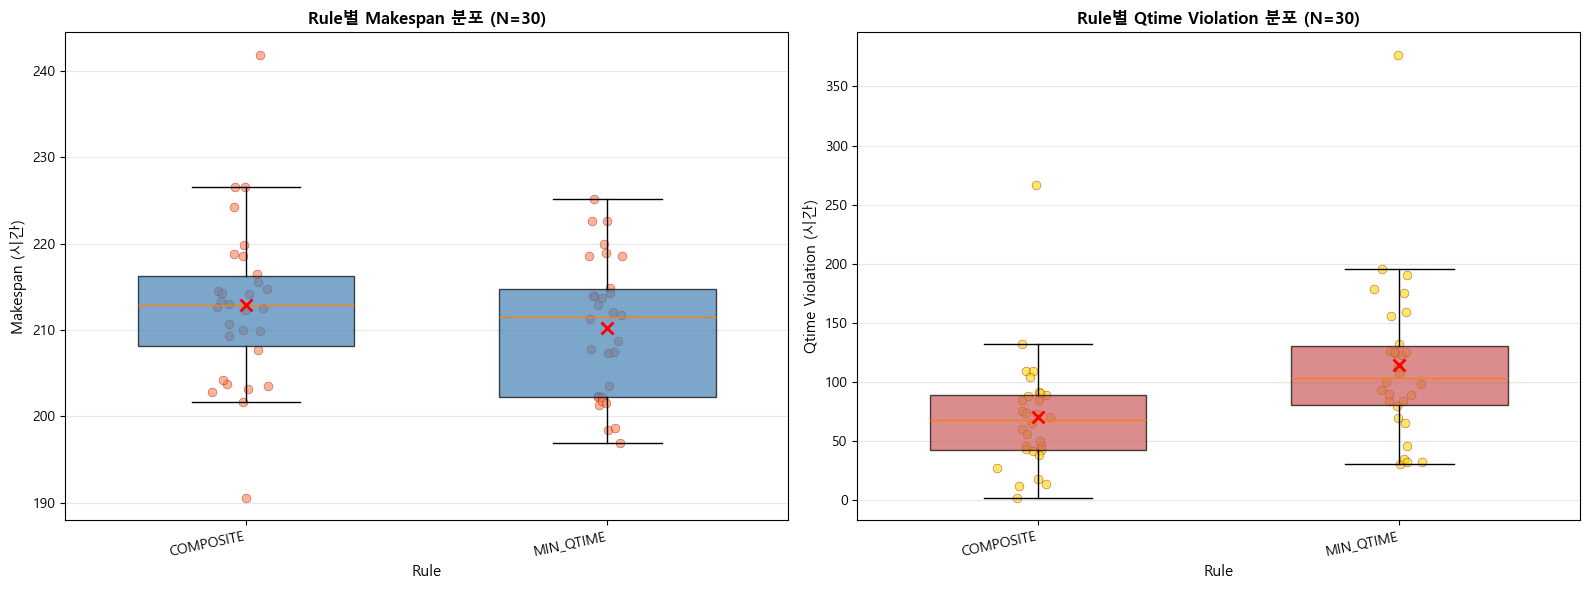

In [6]:
rule_labels = [r[0] for r in RULES]

def _draw_box(ax, col, ylabel, title, box_color='steelblue', dot_color='coral'):
    # 내부 단위는 분. 시각화는 시간(H)으로 변환.
    box_data = [metrics_df[metrics_df['rule'] == lab][col].values / 60.0
                for lab in rule_labels]
    bp = ax.boxplot(box_data, tick_labels=rule_labels, patch_artist=True,
                    widths=0.6, showfliers=False)
    for patch in bp['boxes']:
        patch.set_facecolor(box_color)
        patch.set_alpha(0.7)
    for i, vals in enumerate(box_data):
        x_jit = [i + 1 + np.random.normal(0, 0.04) for _ in vals]
        ax.scatter(x_jit, vals, alpha=0.6, s=40, color=dot_color,
                   edgecolors='darkred', linewidth=0.4)
        ax.plot(i + 1, np.mean(vals), marker='x', markersize=8,
                markeredgewidth=2, color='red', zorder=5)
    ax.set_xlabel('Rule', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    plt.setp(ax.get_xticklabels(), rotation=12, ha='right')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
_draw_box(axes[0], 'makespan', 'Makespan (시간)',
          f'Rule별 Makespan 분포 (N={N_RUNS})')
_draw_box(axes[1], 'qtime_violation', 'Qtime Violation (시간)',
          f'Rule별 Qtime Violation 분포 (N={N_RUNS})',
          box_color='indianred', dot_color='gold')
plt.tight_layout()
plt.show()

## PM=True 실험 (PM Rule별 반복)

위에서 얻은 `metrics_df`(PM=False)는 그대로 두고, **PM=True**로 다시 `THRESHOLD`/`AGE_REPLACEMENT` 두 PM rule을 각각 `N_RUNS`회씩 돌린다. seed 집합은 PM=False와 동일(CRN) → rule × PM rule 비교가 paired.

In [7]:
# PM=False 결과 보존 → 'PM Off'로 라벨링
metrics_off = metrics_df.copy()
metrics_off['pm_mode'] = 'PM Off'

PM_RULES_ON = ['THRESHOLD', 'AGE_REPLACEMENT', 'MTTF']

records_on = []
records_trans_on = []
t_start = time.time()
for pm_rule in PM_RULES_ON:
    os.environ['PM_ACTIVE'] = 'True'
    os.environ['PM_RULE']   = pm_rule
    print(f"=== PM=True / PM_RULE={pm_rule} ===")
    for label, job_rule, composite_w in RULES:
        t0 = time.time()
        for i in range(N_RUNS):
            seed = BASE_SEED + i
            mk, qv, td = run_simulation(job_rule, composite_w, seed)
            records_on.append({
                'rule': label,
                'pm_mode': pm_rule,
                'run': i,
                'seed': seed,
                'makespan': mk,
                'qtime_violation': qv,
            })
            for trans, vio in td.items():
                records_trans_on.append({
                    'rule': label,
                    'pm_mode': pm_rule,
                    'run': i,
                    'seed': seed,
                    'transition': trans,
                    'violation': vio,
                })
        print(f"  [{label:30s}] {N_RUNS}회 완료 ({time.time()-t0:.1f}s)")

# 환경 변수 원복 (PM=False 기본)
os.environ['PM_ACTIVE'] = 'False'
os.environ['PM_RULE']   = 'THRESHOLD'

metrics_on    = pd.DataFrame(records_on)
metrics_all   = pd.concat([metrics_off, metrics_on], ignore_index=True)
metrics_trans = pd.concat(
    [metrics_trans_off, pd.DataFrame(records_trans_on)], ignore_index=True
)
print(f"\n총 소요 {time.time()-t_start:.1f}s, PM=True 결과 shape = {metrics_on.shape}")
print(f"통합 metrics_all shape = {metrics_all.shape}")
print(f"transition 데이터 shape = {metrics_trans.shape}")
metrics_all.head()


=== PM=True / PM_RULE=THRESHOLD ===
  [COMPOSITE                     ] 30회 완료 (19.9s)
  [MIN_QTIME                     ] 30회 완료 (11.2s)
=== PM=True / PM_RULE=AGE_REPLACEMENT ===
  [COMPOSITE                     ] 30회 완료 (22.2s)
  [MIN_QTIME                     ] 30회 완료 (11.6s)
=== PM=True / PM_RULE=MTTF ===
  [COMPOSITE                     ] 30회 완료 (19.0s)
  [MIN_QTIME                     ] 30회 완료 (12.3s)

총 소요 96.2s, PM=True 결과 shape = (180, 6)
통합 metrics_all shape = (240, 6)
transition 데이터 shape = (598, 6)


,rule,run,seed,makespan,qtime_violation,pm_mode
0,COMPOSITE,0,0,12758.728588,5366.265509,PM Off
1,COMPOSITE,1,1,12783.363786,3601.080987,PM Off
2,COMPOSITE,2,2,13592.876146,4514.586073,PM Off
3,COMPOSITE,3,3,13111.096745,6547.612946,PM Off
4,COMPOSITE,4,4,11431.612965,832.762973,PM Off


## Boxplot: Rule × PM Mode 그룹 비교

각 dispatching rule마다 `PM Off` / `THRESHOLD` / `AGE_REPLACEMENT` 세 박스를 나란히 그린다.
- 좌: Makespan 분포
- 우: Qtime Violation 분포

빨간 ×는 평균.

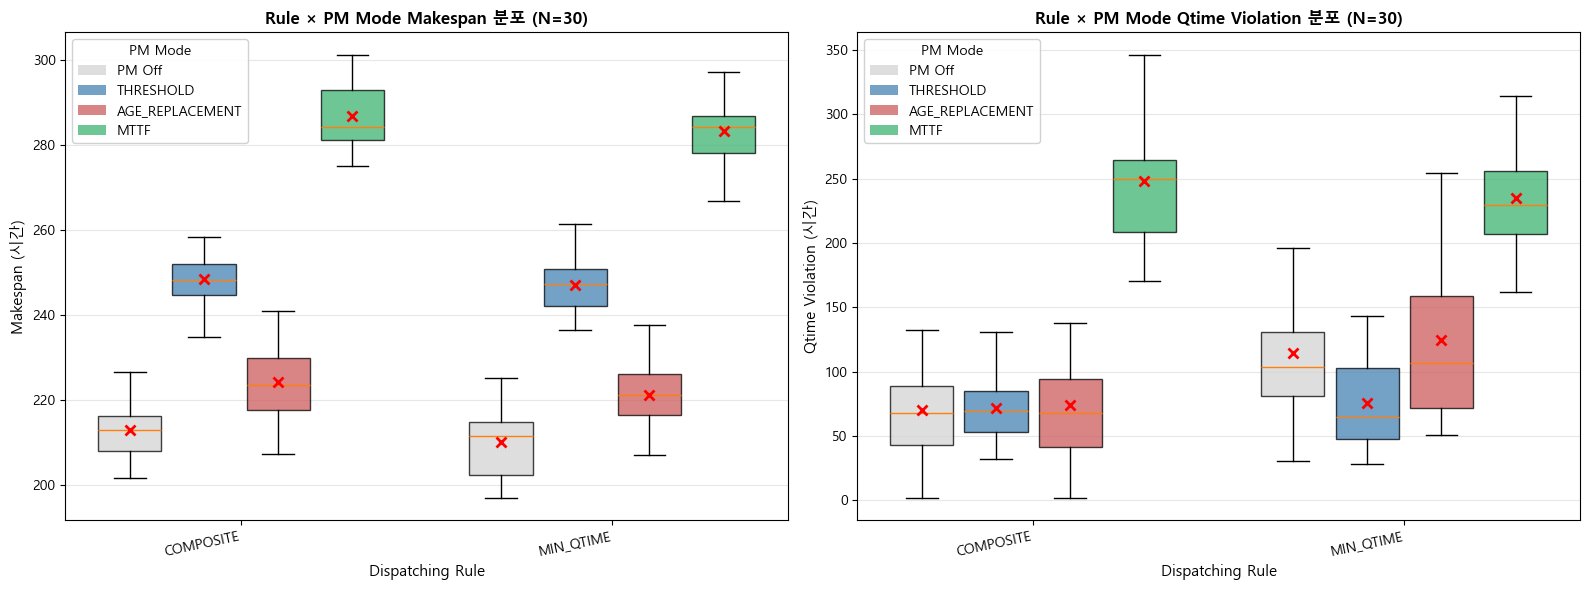

=== Makespan 평균 (시간) ===
pm_mode    PM Off  THRESHOLD  AGE_REPLACEMENT    MTTF
rule                                                 
COMPOSITE  212.90     248.56           224.25  286.84
MIN_QTIME  210.18     247.12           221.17  283.38

=== Qtime Violation 평균 (시간) ===
pm_mode    PM Off  THRESHOLD  AGE_REPLACEMENT    MTTF
rule                                                 
COMPOSITE   70.22      72.19            74.31  248.05
MIN_QTIME  114.62      75.46           124.36  235.15


In [8]:
PM_MODES = ['PM Off', 'THRESHOLD', 'AGE_REPLACEMENT', 'MTTF']
PM_COLORS = {
    'PM Off':          'lightgray',
    'THRESHOLD':       'steelblue',
    'AGE_REPLACEMENT': 'indianred',
    'MTTF':            'mediumseagreen',
}

def _draw_grouped_box(ax, col, ylabel, title):
    n_rules = len(rule_labels)
    n_modes = len(PM_MODES)
    width = 0.8 / n_modes  # 각 박스 폭

    for m_idx, mode in enumerate(PM_MODES):
        positions = [r_idx + 1 + (m_idx - (n_modes - 1) / 2) * width
                     for r_idx in range(n_rules)]
        # 내부 단위는 분. 시각화는 시간(H)으로 변환.
        data = [metrics_all[(metrics_all['rule'] == lab) &
                            (metrics_all['pm_mode'] == mode)][col].values / 60.0
                for lab in rule_labels]
        bp = ax.boxplot(data, positions=positions, widths=width * 0.85,
                        patch_artist=True, showfliers=False,
                        manage_ticks=False)
        for patch in bp['boxes']:
            patch.set_facecolor(PM_COLORS[mode])
            patch.set_alpha(0.75)
        # 평균 ×
        for pos, vals in zip(positions, data):
            if len(vals) > 0:
                ax.plot(pos, np.mean(vals), marker='x', markersize=7,
                        markeredgewidth=2, color='red', zorder=5)

    ax.set_xticks(range(1, n_rules + 1))
    ax.set_xticklabels(rule_labels, rotation=12, ha='right')
    ax.set_xlabel('Dispatching Rule', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

    # 범례
    from matplotlib.patches import Patch
    handles = [Patch(facecolor=PM_COLORS[m], alpha=0.75, label=m) for m in PM_MODES]
    ax.legend(handles=handles, loc='best', framealpha=0.9, title='PM Mode')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
_draw_grouped_box(axes[0], 'makespan', 'Makespan (시간)',
                  f'Rule × PM Mode Makespan 분포 (N={N_RUNS})')
_draw_grouped_box(axes[1], 'qtime_violation', 'Qtime Violation (시간)',
                  f'Rule × PM Mode Qtime Violation 분포 (N={N_RUNS})')
plt.tight_layout()
plt.show()

# 요약 표 (시간 단위)
print("=== Makespan 평균 (시간) ===")
print((metrics_all.groupby(['rule', 'pm_mode'])['makespan'].mean() / 60.0)
      .unstack('pm_mode').reindex(rule_labels)[PM_MODES].round(2).to_string())
print("\n=== Qtime Violation 평균 (시간) ===")
print((metrics_all.groupby(['rule', 'pm_mode'])['qtime_violation'].mean() / 60.0)
      .unstack('pm_mode').reindex(rule_labels)[PM_MODES].round(2).to_string())

## Q-Time 위반 Transition 분석 — Rule × PM Mode

각 dispatching rule을 subplot으로 두고, x축은 transition, 막대는 PM Mode별 그룹.
- 값은 `N_RUNS` 평균 Q-Time 위반 시간(시간 단위)
- qtime이 부여된 transition만 비공(0이 아닌) 막대를 가짐 (G1→G3, G1→G4, G4→G1)

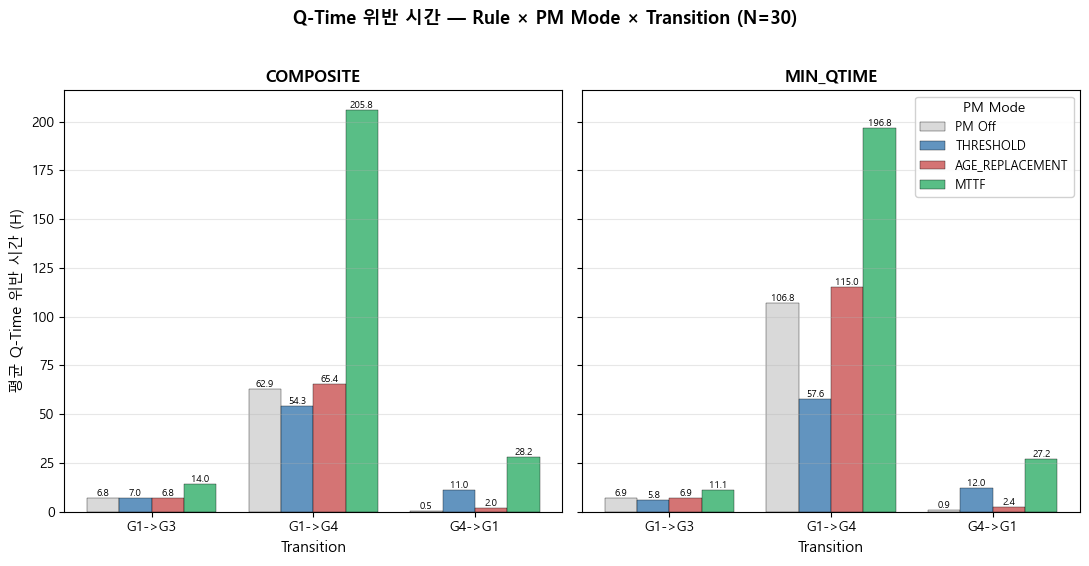

=== Q-Time 위반 평균 (시간) — rule × pm_mode × transition ===
pm_mode               PM Off  THRESHOLD  AGE_REPLACEMENT    MTTF
rule      transition                                            
COMPOSITE G1->G3        6.84       6.97             6.84   14.01
          G1->G4       62.88      54.26            65.43  205.81
          G4->G1        0.50      10.95             2.04   28.24
MIN_QTIME G1->G3        6.94       5.80             6.94   11.11
          G1->G4      106.79      57.61           114.99  196.81
          G4->G1        0.89      12.04             2.44   27.23


In [9]:
# Rule × PM Mode × Transition 평균 위반 시간 (분 → 시간 변환).
# qtime이 설정된 transition만 의미 있는 값을 가짐.
QTIME_TRANSITIONS = ['G1->G3', 'G1->G4', 'G4->G1']  # CLAUDE.md: G1→G3(600), G1→G4(480), G4→G1(1440)

# run별 합계 → rule×pm_mode×transition 평균 (run에 없는 transition은 0으로 채움)
_full_idx = pd.MultiIndex.from_product(
    [rule_labels, PM_MODES, range(N_RUNS), QTIME_TRANSITIONS],
    names=['rule', 'pm_mode', 'run', 'transition'],
)
trans_per_run = (metrics_trans
                 .groupby(['rule', 'pm_mode', 'run', 'transition'])['violation']
                 .sum()
                 .reindex(_full_idx, fill_value=0.0)
                 .reset_index())
trans_summary = (trans_per_run
                 .groupby(['rule', 'pm_mode', 'transition'])['violation']
                 .mean()
                 .div(60.0)  # 분 → 시간
                 .reset_index())

fig, axes = plt.subplots(1, len(rule_labels),
                         figsize=(5.5 * len(rule_labels), 5.5), sharey=True)
if len(rule_labels) == 1:
    axes = [axes]

n_modes = len(PM_MODES)
width = 0.8 / n_modes
x = np.arange(len(QTIME_TRANSITIONS))

for ax, rule in zip(axes, rule_labels):
    sub = trans_summary[trans_summary['rule'] == rule]
    pivot = (sub.pivot(index='transition', columns='pm_mode', values='violation')
             .reindex(QTIME_TRANSITIONS)
             .reindex(PM_MODES, axis=1)
             .fillna(0.0))
    for m_idx, mode in enumerate(PM_MODES):
        vals = pivot[mode].values
        offset = (m_idx - (n_modes - 1) / 2) * width
        bars = ax.bar(x + offset, vals, width,
                      label=mode, color=PM_COLORS[mode], alpha=0.85,
                      edgecolor='black', linewidth=0.3)
        for bar, v in zip(bars, vals):
            if v > 0.05:
                ax.text(bar.get_x() + bar.get_width() / 2, v,
                        f'{v:.1f}', ha='center', va='bottom', fontsize=7)
    ax.set_xticks(x)
    ax.set_xticklabels(QTIME_TRANSITIONS, rotation=0)
    ax.set_xlabel('Transition', fontsize=11)
    ax.set_title(rule, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

axes[0].set_ylabel('평균 Q-Time 위반 시간 (H)', fontsize=11)
axes[-1].legend(title='PM Mode', loc='upper right', fontsize=9, framealpha=0.9)
plt.suptitle(f'Q-Time 위반 시간 — Rule × PM Mode × Transition (N={N_RUNS})',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 표 출력 (시간 단위)
trans_table = (trans_summary
               .pivot_table(index=['rule', 'transition'],
                            columns='pm_mode', values='violation')
               .reindex(PM_MODES, axis=1)
               .reindex(pd.MultiIndex.from_product([rule_labels, QTIME_TRANSITIONS],
                                                    names=['rule', 'transition']))
               .round(2))
print("=== Q-Time 위반 평균 (시간) — rule × pm_mode × transition ===")
print(trans_table.to_string())
